# **PROJECT TITLE**  
**Predicting Global Life Expectancy; An End-to-End Machine Learning Framework for Socio-Economic and Health Determinants**
---
## **OBJECTIVES**
* To Clean and preprocess the dataset by handling missing values and encoding categorical status variables.
* To Identify key correlations between socio-economic factors and life expectancy through bivariate and multivariate exploration.
* To Develop a predictive regression model to estimate lifespan based on health and economic indicators.
* To Quantify the specific impact of healthcare expenditure and schooling on national life expectancy averages.
* To Extract feature importance to determine which variables most significantly affect human longevity.

### **Dataset Overview**
| Field | Description | Type |
| :--- | :--- | :--- |
| `Country` | Name of the nation being observed. | String |
| `Year` | The specific year of data collection (ranging from 2000 to 2015). | Integer |
| `Status` | Categorization of the country as either 'Developed' or 'Developing'. | String |
| `Life expectancy` | The average number of years a person is expected to live. | Float |
| `Adult Mortality` | Probability of dying between 15 and 60 years per 1000 population. | Float |
| `infant deaths` | Number of infant deaths per 1000 population. | Integer |
| `Alcohol` | Recorded per capita (15+) consumption (in litres of pure alcohol). | Float |
| `percentage expenditure` | Health expenditure as a percentage of GDP per capita. | Float |
| `Hepatitis B` | Immunization coverage (%) among 1-year-olds for Hepatitis B. | Float |
| `Measles` | Number of reported measles cases per 1000 population. | Integer |
| `BMI` | Average Body Mass Index of the entire population. | Float |
| `under-five deaths` | Number of deaths of children under five years old per 1000 population. | Integer |
| `Polio` | Immunization coverage (%) among 1-year-olds for Polio. | Float |
| `Total expenditure` | General government expenditure on health as a % of total government expenditure. | Float |
| `Diphtheria` | Immunization coverage (%) among 1-year-olds for Diphtheria, tetanus, and pertussis. | Float |
| `HIV/AIDS` | Deaths per 1000 live births caused by HIV/AIDS (ages 0-4). | Float |
| `GDP` | Gross Domestic Product per capita (in USD). | Float |
| `Population` | Total population count of the country. | Float |
| `thinness 1-19 years` | Prevalence of thinness among children and adolescents (ages 1 to 19) (%). | Float |
| `thinness 5-9 years` | Prevalence of thinness among children (ages 5 to 9) (%). | Float |
| `Income composition of resources` | Human Development Index in terms of income composition of resources. | Float |
| `Schooling` | Average number of years of schooling. | Float |


In [1]:
# Importing necessary libraries

# Data preprocessing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.impute import KNNImputer

#feature engineering
from sklearn.preprocessing import StandardScaler

# model development
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing required libraries for Kaggle API and environment variable management
%pip install kaggle python-dotenv

import os
from dotenv import load_dotenv
from kaggle.api.kaggle_api_extended import KaggleApi

# Loading environment variables from .env file
load_dotenv()

# Authenticating with Kaggle API using loaded credentials
api = KaggleApi()
api.authenticate()

# Downloading the dataset using the Kaggle API
dataset_slug = 'kumarajarshi/life-expectancy-who'
api.dataset_download_files(dataset_slug, path='./data', unzip=True)

print("Credentials loaded from .env and dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who
Credentials loaded from .env and dataset downloaded!


In [2]:
# Loading the dataset into a pandas DataFrame
path = '../data/Life Expectancy Data.csv'
df = pd.read_csv(path)
# Displaying the first few rows of the DataFrame to verify successful loading
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


### **DATA WRANGLING & PREPROCESSING**
#### **DATA AUDIT**

In [3]:
# defining a function for structural profiling of the dataset

def structural_profiling(df):
    """
    Performs an exhaustive structural audit of a DataFrame.
    """
    print("-" * 30)
    print("STRUCTURAL PROFILING REPORT")
    print("-" * 30)
    
    # Dimensionality Assessment
    print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
    
    # Schema Identification (Data Types)
    print("\nColumn Schema (Data Types):")
    print(df.dtypes)
    
    # Memory Footprint
    total_memory = df.memory_usage(deep=True).sum() / 1024
    print(f"\nTotal Memory Usage: {total_memory:.2f} KB")
    
    # Indexing Structure
    print(f"\nIndex Type: {type(df.index).__name__}")
    
    # Column Name Assessment (Checking for spaces/special chars)
    print("\nColumn Names Audit:")
    print(list(df.columns))
    
    print("-" * 30)

# Execution
structural_profiling(df)

------------------------------
STRUCTURAL PROFILING REPORT
------------------------------
Dimensions: 2938 rows, 22 columns

Column Schema (Data Types):
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years           

In [4]:
# defining a function for content profiling of the dataset
def content_profiling(df):
    """
    Performs an exhaustive statistical summary and returns diagnostic DataFrames
    for both numerical and categorical features.
    """
    print("-" * 30)
    print("CONTENT PROFILING REPORT")
    print("-" * 30)
    
    # Numerical Statistical Summary
    numeric_df = df.select_dtypes(include=['number'])
    
    if not numeric_df.empty:
        # Generate base descriptive statistics
        stats_df = numeric_df.describe().T
        
        # Calculate extended distribution metrics
        stats_df['variance'] = numeric_df.var()
        stats_df['skewness'] = numeric_df.skew()
        stats_df['kurtosis'] = numeric_df.kurt()
        
        # Rounding for clinical readability
        stats_df = stats_df.round(3)
        
        print("\n[A] Numerical Feature Profile:")
        print(stats_df.to_string()) # Ensures all columns are printed in the terminal/cell
    else:
        print("\n[A] Numerical Feature Profile: No numerical columns found.")

    # Categorical Mode Profiling
    cat_df = df.select_dtypes(include=['object', 'category'])
    
    if not cat_df.empty:
        mode_data = []
        for col in cat_df.columns:
            # Calculate mode and frequency of the mode
            mode_series = cat_df[col].mode()
            mode_val = mode_series.iloc[0] if not mode_series.empty else "N/A"
            freq = cat_df[col].value_counts().max()
            pct = (freq / len(df)) * 100
            
            mode_data.append({
                'Feature': col,
                'Top Value (Mode)': mode_val,
                'Frequency': freq,
                'Prevalence (%)': f"{pct:.2f}%"
            })
        
        # Converting to DataFrame
        categorical_summary = pd.DataFrame(mode_data).set_index('Feature')
        
        print("\n[B] Categorical Feature Profile (Dominant Values):")
        print(categorical_summary.to_string())
    else:
        print("\n[B] Categorical Feature Profile: No categorical columns found.")
    
    print("-" * 30)

# Execution
content_profiling(df)

------------------------------
CONTENT PROFILING REPORT
------------------------------

[A] Numerical Feature Profile:
                                  count          mean           std       min         25%          50%          75%           max      variance  skewness  kurtosis
Year                             2938.0  2.007519e+03  4.614000e+00  2000.000    2004.000     2008.000     2012.000  2.015000e+03  2.128800e+01    -0.006    -1.214
Life expectancy                  2928.0  6.922500e+01  9.524000e+00    36.300      63.100       72.100       75.700  8.900000e+01  9.070400e+01    -0.639    -0.234
Adult Mortality                  2928.0  1.647960e+02  1.242920e+02     1.000      74.000      144.000      228.000  7.230000e+02  1.544852e+04     1.174     1.749
infant deaths                    2938.0  3.030400e+01  1.179270e+02     0.000       0.000        3.000       22.000  1.800000e+03  1.390666e+04     9.787   116.043
Alcohol                          2744.0  4.603000e+00  4.0520

In [5]:
# defining a function for quality profiling of the dataset
def quality_profiling(df):
    """
    Performs a systematic audit of data completeness, uniqueness, and validity,
    returning findings in structured DataFrames.
    """
    print("-" * 30)
    print("QUALITY PROFILING REPORT")
    print("-" * 30)

    # 1. Completeness Audit (DataFrame)
    null_counts = df.isnull().sum()
    null_pct = (df.isnull().sum() / len(df)) * 100
    completeness_df = pd.DataFrame({
        'Missing Values': null_counts, 
        'Percentage (%)': null_pct.round(2)
    })
    
    print("\n[A] Completeness Audit (Features with Nulls):")
    # Only showing columns with missing data for brevity
    null_only = completeness_df[completeness_df['Missing Values'] > 0]
    if not null_only.empty:
        print(null_only.to_string())
    else:
        print("No missing values detected.")

    # 2. Uniqueness Analysis
    duplicates = df.duplicated().sum()
    print(f"\n[B] Uniqueness Analysis:")
    print(f"Total Duplicate Rows: {duplicates}")

    # 3. Combined Validity & Outlier Audit (Numerical DataFrame)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if not numeric_cols.empty:
        quality_data = []
        for col in numeric_cols:
            # Range Check
            col_min = df[col].min()
            col_max = df[col].max()
            
            # Outlier Screening (IQR Method)
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
            
            quality_data.append({
                'Feature': col,
                'Min': col_min,
                'Max': col_max,
                'IQR Outliers': outliers
            })
        
        validity_df = pd.DataFrame(quality_data).set_index('Feature')
        print("\n[C] Numerical Quality Audit (Validity & Outliers):")
        print(validity_df.to_string())
    else:
        print("\n[C] Numerical Quality Audit: No numerical columns found.")
    
    print("-" * 30)

# Execution
quality_profiling(df)

------------------------------
QUALITY PROFILING REPORT
------------------------------

[A] Completeness Audit (Features with Nulls):
                                 Missing Values  Percentage (%)
Life expectancy                              10            0.34
Adult Mortality                              10            0.34
Alcohol                                     194            6.60
Hepatitis B                                 553           18.82
 BMI                                         34            1.16
Polio                                        19            0.65
Total expenditure                           226            7.69
Diphtheria                                   19            0.65
GDP                                         448           15.25
Population                                  652           22.19
 thinness  1-19 years                        34            1.16
 thinness 5-9 years                          34            1.16
Income composition of resources   

------------------------------
RELATIONSHIP & DISTRIBUTION REPORT
------------------------------

Cardinality & Class Balance (Categorical):
Country: 193 unique values. Top: 'Afghanistan' (0.5%)
Status: 2 unique values. Top: 'Developing' (82.6%)

Generating Numerical Correlation Heatmap...


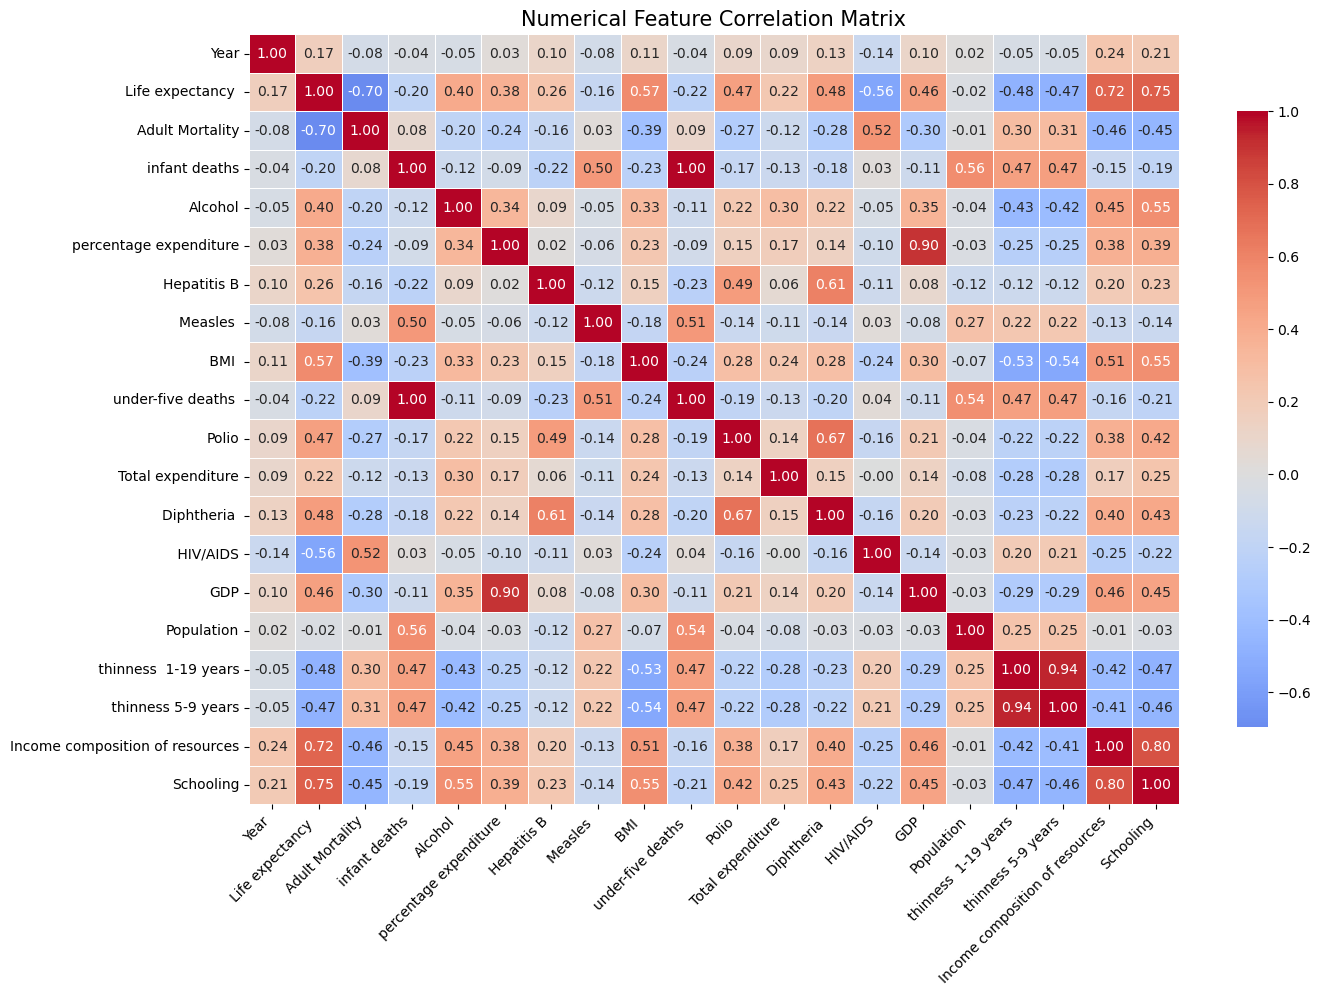


Potential Redundancy Check (Categorical):
No redundancy detected between 'Country' and 'Status'.
------------------------------


In [6]:
# defining a function for relationship and distribution profiling of the dataset
def relationship_distribution_profiling(df):
    """
    Performs a systematic profiling of data distributions and feature relationships
    with visual correlation mapping.
    """
    print("-" * 30)
    print("RELATIONSHIP & DISTRIBUTION REPORT")
    print("-" * 30)

    # Distribution Profiling: Cardinality & Class Balance
    print("\nCardinality & Class Balance (Categorical):")
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if not cat_cols.empty:
        for col in cat_cols:
            unique_count = df[col].nunique()
            top_value = df[col].value_counts().idxmax()
            top_pct = (df[col].value_counts().max() / len(df)) * 100
            print(f"{col}: {unique_count} unique values. Top: '{top_value}' ({top_pct:.1f}%)")
    else:
        print("No categorical columns detected.")

    # Visual Relationship Profiling: Correlation Heatmap (Numerical)
    print("\nGenerating Numerical Correlation Heatmap...")
    numeric_df = df.select_dtypes(include=['number'])
    
    if not numeric_df.empty:
        # Calculate Correlation
        corr_matrix = numeric_df.corr()
        
        # Plotting
        plt.figure(figsize=(15, 10))
        sns.heatmap(corr_matrix, 
                    annot=True,          # Show the numbers
                    fmt=".2f",           # 2 decimal places
                    cmap='coolwarm',     # Red for positive, Blue for negative
                    center=0,            # 0 is the neutral color
                    linewidths=0.5, 
                    cbar_kws={"shrink": .8})
        
        plt.title('Numerical Feature Correlation Matrix', fontsize=15)
        plt.xticks(rotation=45, ha='right')
        plt.savefig('../visuals/relationship.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("No numerical columns available for correlation.")

    # Feature Dependencies (Checking for redundancy)
    print("\nPotential Redundancy Check (Categorical):")
    for i in range(len(cat_cols)):
        for j in range(i + 1, len(cat_cols)):
            col1, col2 = cat_cols[i], cat_cols[j]
            if df[col1].nunique() == df[col2].nunique():
                print(f"Possible redundancy found between '{col1}' and '{col2}'.")
            else:
                print(f"No redundancy detected between '{col1}' and '{col2}'.")
    
    print("-" * 30)

# Execution
relationship_distribution_profiling(df)

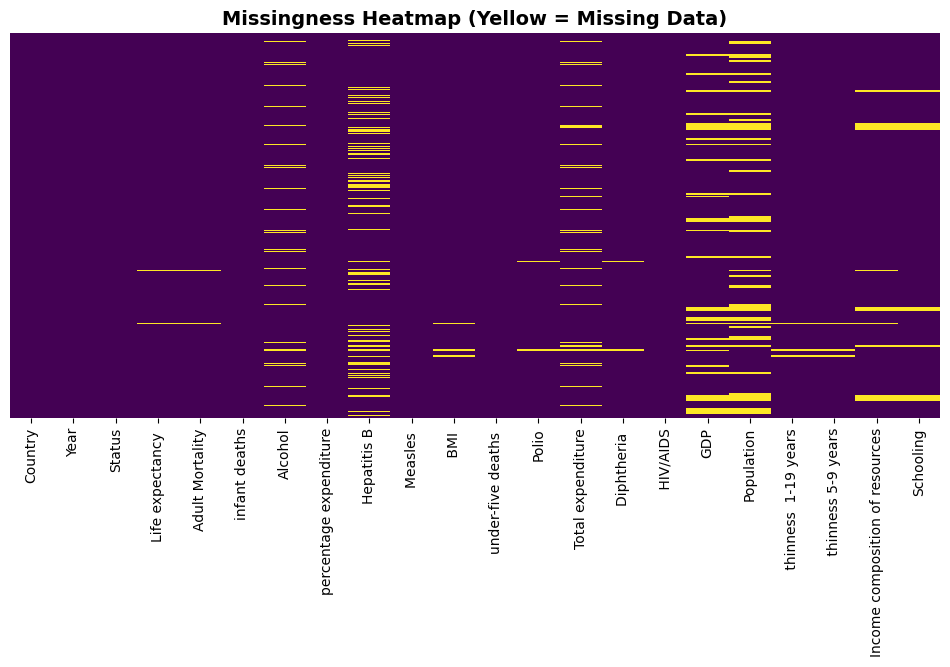

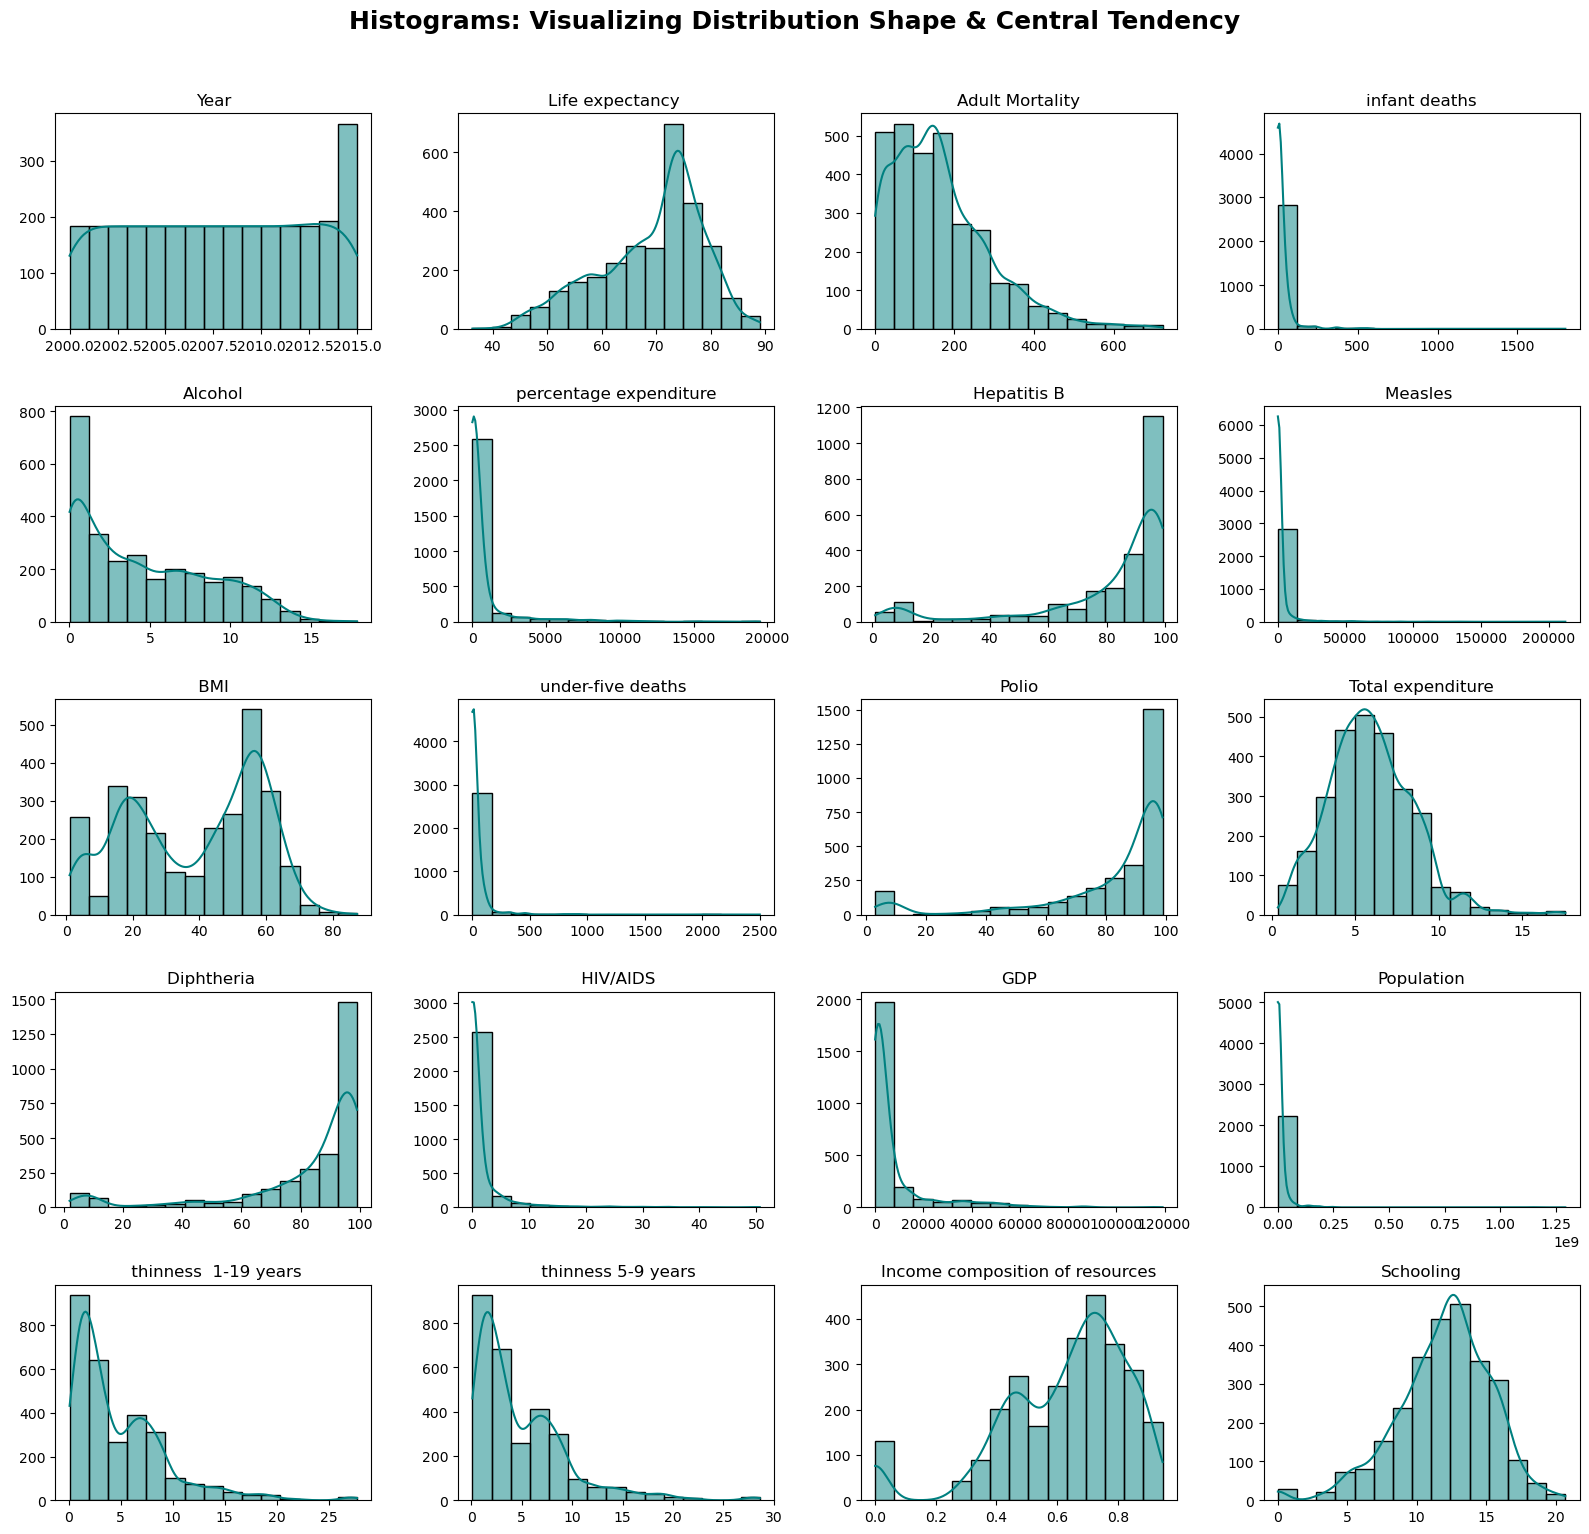

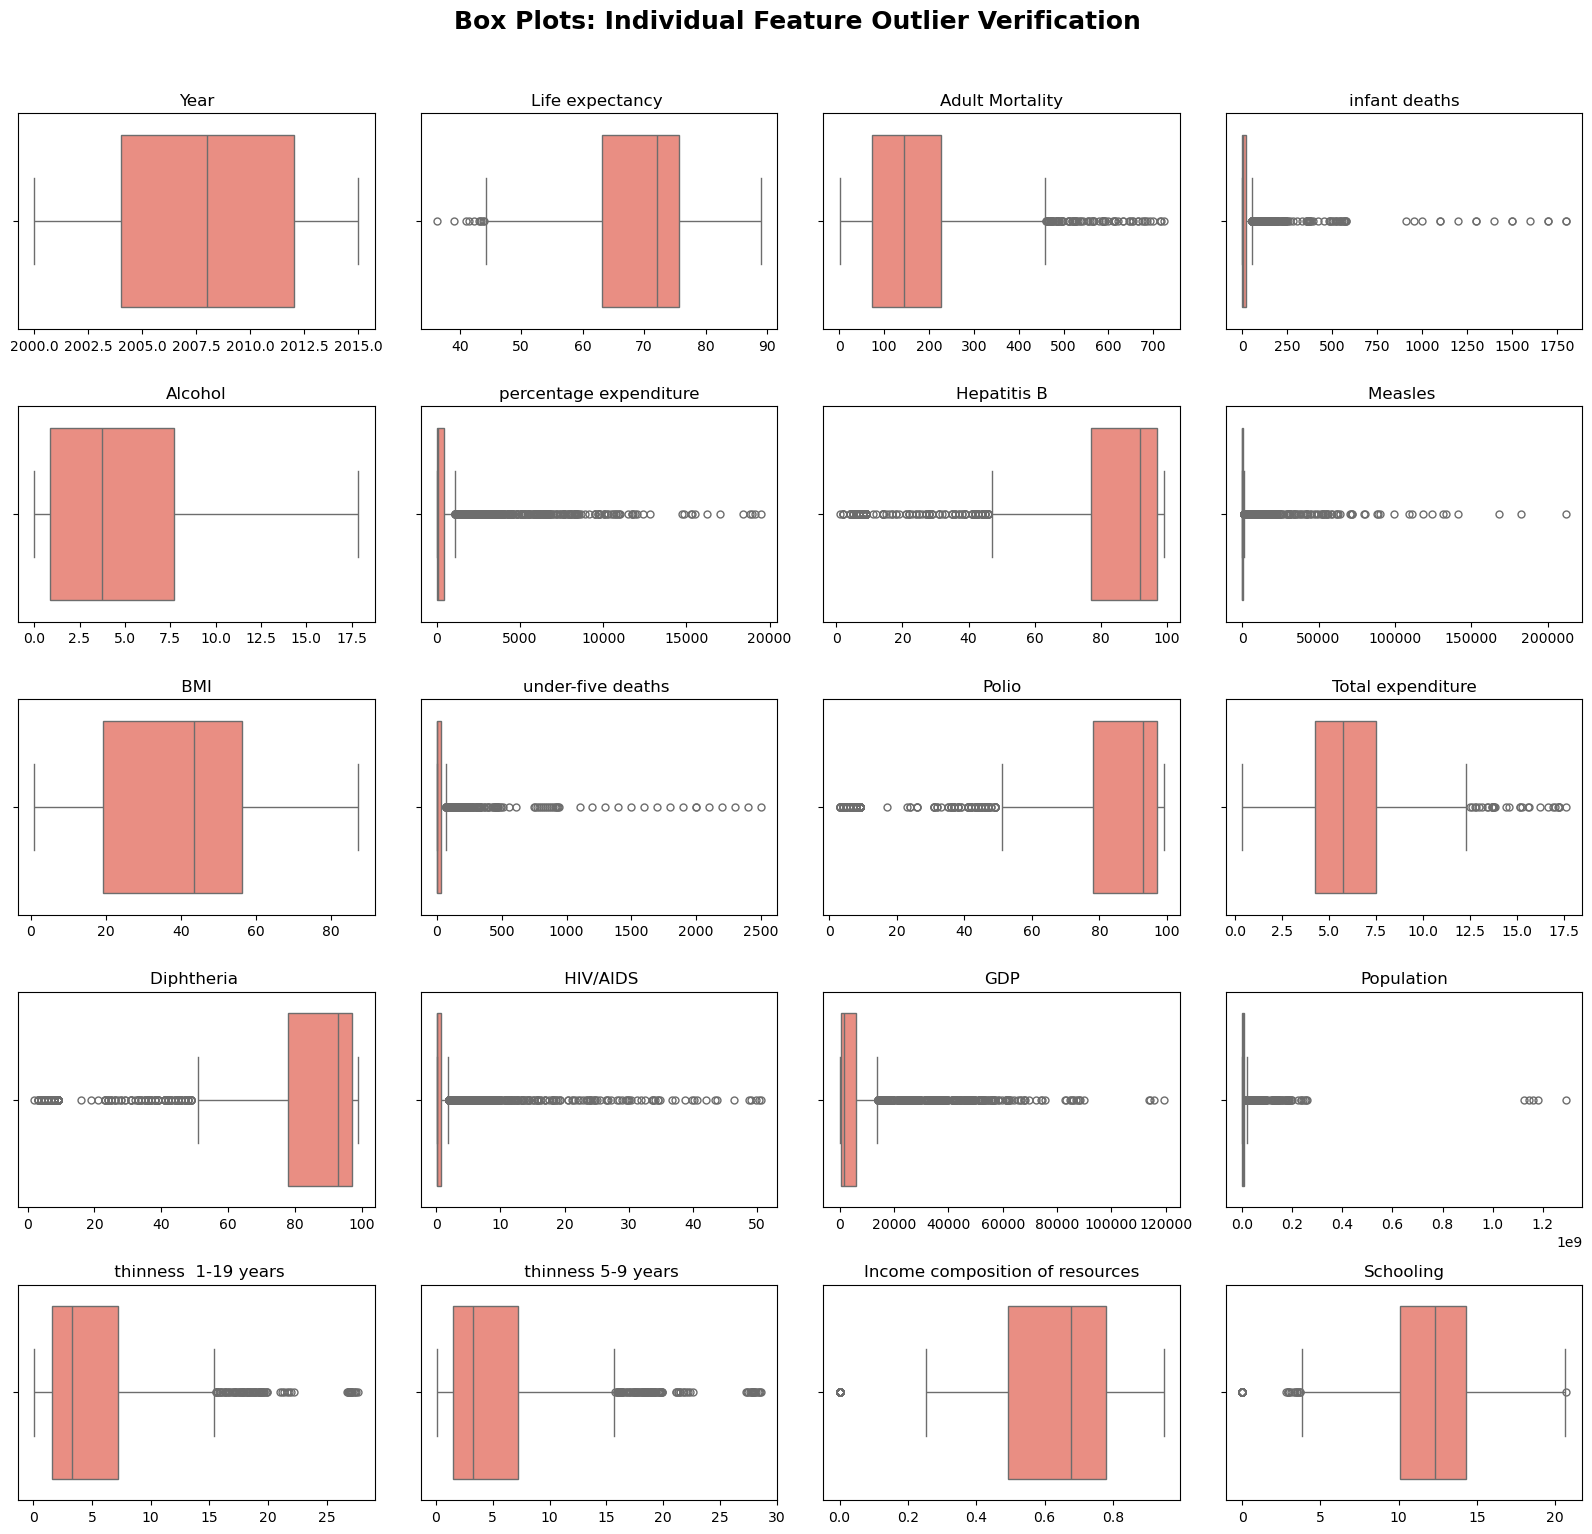

In [7]:

def generate_diagnostic_plots(df):
    """
    Creates high-resolution visual diagnostics for Data Profiling.
    Optimized for healthcare datasets with multiple numeric scales.
    """

    # Missingness Heatmap
    plt.figure(figsize=(12, 5))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title('Missingness Heatmap (Yellow = Missing Data)', fontsize=14, fontweight='bold')
    plt.savefig('../visuals/diagnostic_plot_1.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Identifying all numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_count = len(numeric_cols)
    
    if num_count > 0:
        # Dynamic Grid Calculation: Ensures subplots fit perfectly
        cols = 4
        rows = math.ceil(num_count / cols)

        # Histograms: Distribution & Skewness Audit
        # using faceted subplots so each feature has its own x-axis scale
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
        axes = axes.flatten()
        
        for i, col in enumerate(numeric_cols):
            sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=15)
            axes[i].set_title(f'{col}', fontsize=12)
            axes[i].set_xlabel('')
            axes[i].set_ylabel('')

        # Hide empty subplot slots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.suptitle('Histograms: Visualizing Distribution Shape & Central Tendency', 
                     fontsize=18, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('../visuals/diagnostic_plot_2.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Boxplots: Clinical Outlier Verification
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
        axes = axes.flatten()
        
        for i, col in enumerate(numeric_cols):
            sns.boxplot(x=df[col], ax=axes[i], color='salmon', fliersize=5)
            axes[i].set_title(f'{col}', fontsize=12)
            axes[i].set_xlabel('')

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle('Box Plots: Individual Feature Outlier Verification', 
                     fontsize=18, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('../visuals/diagnostic_plot_3.png', dpi=300, bbox_inches='tight')
        plt.show()

# Execution
generate_diagnostic_plots(df)

#### **Data Quality Audit Report:**


#### 1. Structural Observations
* **Schema Integrity:** 
    * The `status` column is *stored* as an Object and needs conversion to *category*
    * The `population` column is *stored* as a float and needs conversion to *int*
    
* **Naming** 
    * Some col names have trailing spaces and needs to be reset

#### 2. Content & Statistical Findings
* **Skewness:**
    * The `percentage expenditure` column is highly right-skewed
    * Skewness in other columns are expected
* **Range Outliers:**
    * `percentage expenditure`:  389 outliers detected as it should be in the range of 0-100%

#### 3. Quality Issues
* **Missingness:**
    | Column | Perc of missingness | Missingness Type |
    | :--- | :--- | :--- |
    | `Life expectancy` | 0.34% | MCAR |
    | `Adult Mortality` | 0.34% | MCAR |
    | `Alcohol` | 6.60% | MAR |
    | `Hepatitis B` | 18.82% | MAR |
    | `BMI` | 1.16% | MAR |
    | `Polio` | 0.65% | MCAR |
    | `Total expenditure` | 7.69% | MAR |
    | `Diphtheria` | 0.65% | MCAR |
    | `GDP` | 15.25% | MAR |
    | `Population` | 22.19% | MAR |
    | `thinness 1-19 years` | 1.16% | MAR |
    | `thinness 5-9 years` | 1.16% | MAR |
    | `Income composition of resources` | 5.68% | MAR |
    | `Schooling` | 5.55% | MAR |

* **Duplicates:** 
    * No row duplicates found
* **Validity Errors:** 
    * percentage expenditure

#### 4. Proposed Cleaning Strategy (Data Cleaning)
2. **Type Casting:** 
    * Convert `status` to category
    * convert `population` to int
3. **Imputation:**   
    | Column | Imputation Strategy |
    | :--- | :--- |
    | `Life expectancy` | Global Median |
    | `Adult Mortality` | Global Median |
    | `Alcohol` | Grouped Median (Country) |
    | `Hepatitis B` | Grouped Median (Status) |
    | `BMI` | Grouped Median (Country) |
    | `Polio` | Global Median |
    | `Total expenditure` | Grouped Median (Status) |
    | `Diphtheria` | Global Median |
    | `GDP` | KNN Imputation |
    | `Population` | Linear Interpolation |
    | `thinness 1-19 years` | Grouped Median (Country) |
    | `thinness 5-9 years` | MAR | Grouped Median (Country) |
    | `Income composition of resources` | Grouped Median (Status) |
    | `Schooling` | Grouped Median (Status) |

#### **DATA CLEANING**

In [8]:
# Cleaning column names
df.columns = df.columns.str.strip()

# Converting Status to category
df['Status'] = df['Status'].astype('category')

# Handling Validity Errors in percentage expenditure
# Values > 100 are flagged as NaN for later imputation
df.loc[df['percentage expenditure'] > 100, 'percentage expenditure'] = np.nan

In [9]:
# Imputing Missing Values for MCAR Columns using the global Median
mcar_cols = ['Life expectancy', 'Adult Mortality', 'Polio', 'Diphtheria']
for col in mcar_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
print(df.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [11]:
# Grouping by Country (Biological/Cultural indicators)
country_mar_cols = ['Alcohol', 'BMI', 'thinness  1-19 years', 'thinness 5-9 years']
for col in country_mar_cols:
    df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.median()))

# Grouping by Status (Economic/Policy indicators)
status_mar_cols = ['Hepatitis B', 'Total expenditure', 'Income composition of resources', 'Schooling']
for col in status_mar_cols:
    df[col] = df.groupby('Status')[col].transform(lambda x: x.fillna(x.median()))

In [12]:
# Linear Interpolation for Population using Time-series logic
df['Population'] = df.groupby('Country')['Population'].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

# Fallback for Population gaps using Status median
df['Population'] = df['Population'].fillna(df.groupby('Status')['Population'].transform('median'))

# KNN Imputation for GDP
knn_imputer = KNNImputer(n_neighbors=5)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])

# Final conversion for Population to Integer
df['Population'] = df['Population'].astype(int)

#### **DATA VALIDATION**

In [13]:
# Completeness Verification
print("-" * 30)
print("INTEGRITY CHECK REPORT")
print("-" * 30)

# Null Check
total_nulls = df.isnull().sum().sum()
print(f"1. Completeness Status: {'PASSED' if total_nulls == 0 else 'FAILED'}")
print(f"   Total Remaining Nulls: {total_nulls}")

# Schema Validation
expected_types = {'Status': 'category', 'Population': 'int32'} # or int64
print(f"\n2. Schema Status:")
print(f"   Status Column: {df['Status'].dtype}")
print(f"   Population Column: {df['Population'].dtype}")

# Biological/Logical Range Validation
# checking the critical boundaries identified in the audit
validation_ranges = {
    'percentage expenditure': (0, 100)
}

range_results = []
for col, (min_val, max_val) in validation_ranges.items():
    actual_min = df[col].min()
    actual_max = df[col].max()
    is_valid = (actual_min >= min_val) and (actual_max <= max_val)
    
    range_results.append({
        'Feature': col,
        'Actual Min': actual_min,
        'Actual Max': actual_max,
        'Status': 'Valid' if is_valid else 'Warning: Out of Range'
    })

validation_df = pd.DataFrame(range_results).set_index('Feature')
print("\n3. Logical Boundary Audit:")
print(validation_df.to_string())

# Final Shape Confirmation
print(f"\n4. Final Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("-" * 30)

------------------------------
INTEGRITY CHECK REPORT
------------------------------
1. Completeness Status: PASSED
   Total Remaining Nulls: 0

2. Schema Status:
   Status Column: category
   Population Column: int64

3. Logical Boundary Audit:
                        Actual Min  Actual Max Status
Feature                                              
percentage expenditure         0.0   99.080954  Valid

4. Final Dimensions: 2938 rows, 22 columns
------------------------------


### **EXPLORATORY DATA ANALYSIS (EDA)**
---
#### **UNIVARIATE ANALYSIS**
*  Objectives:

    * To Evaluate the distribution of the target variable (Life expectancy) to identify the global average and range of human longevity.

    * To Quantify the class balance between Developed and Developing nations to identify potential geographic biases in the dataset.

    * To Analyze the skewness and central tendency of clinical and economic predictors (e.g., Adult Mortality, GDP, Schooling).

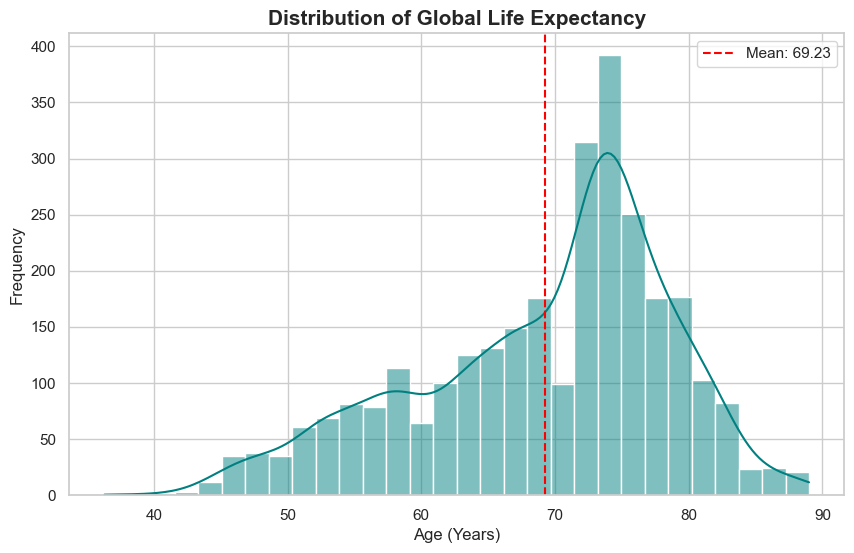

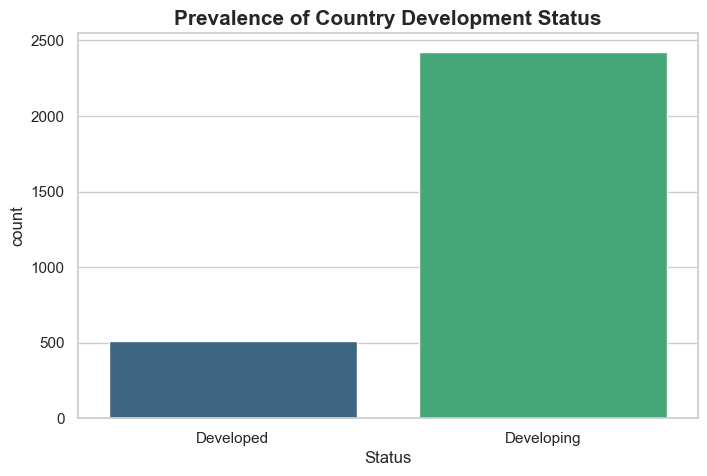

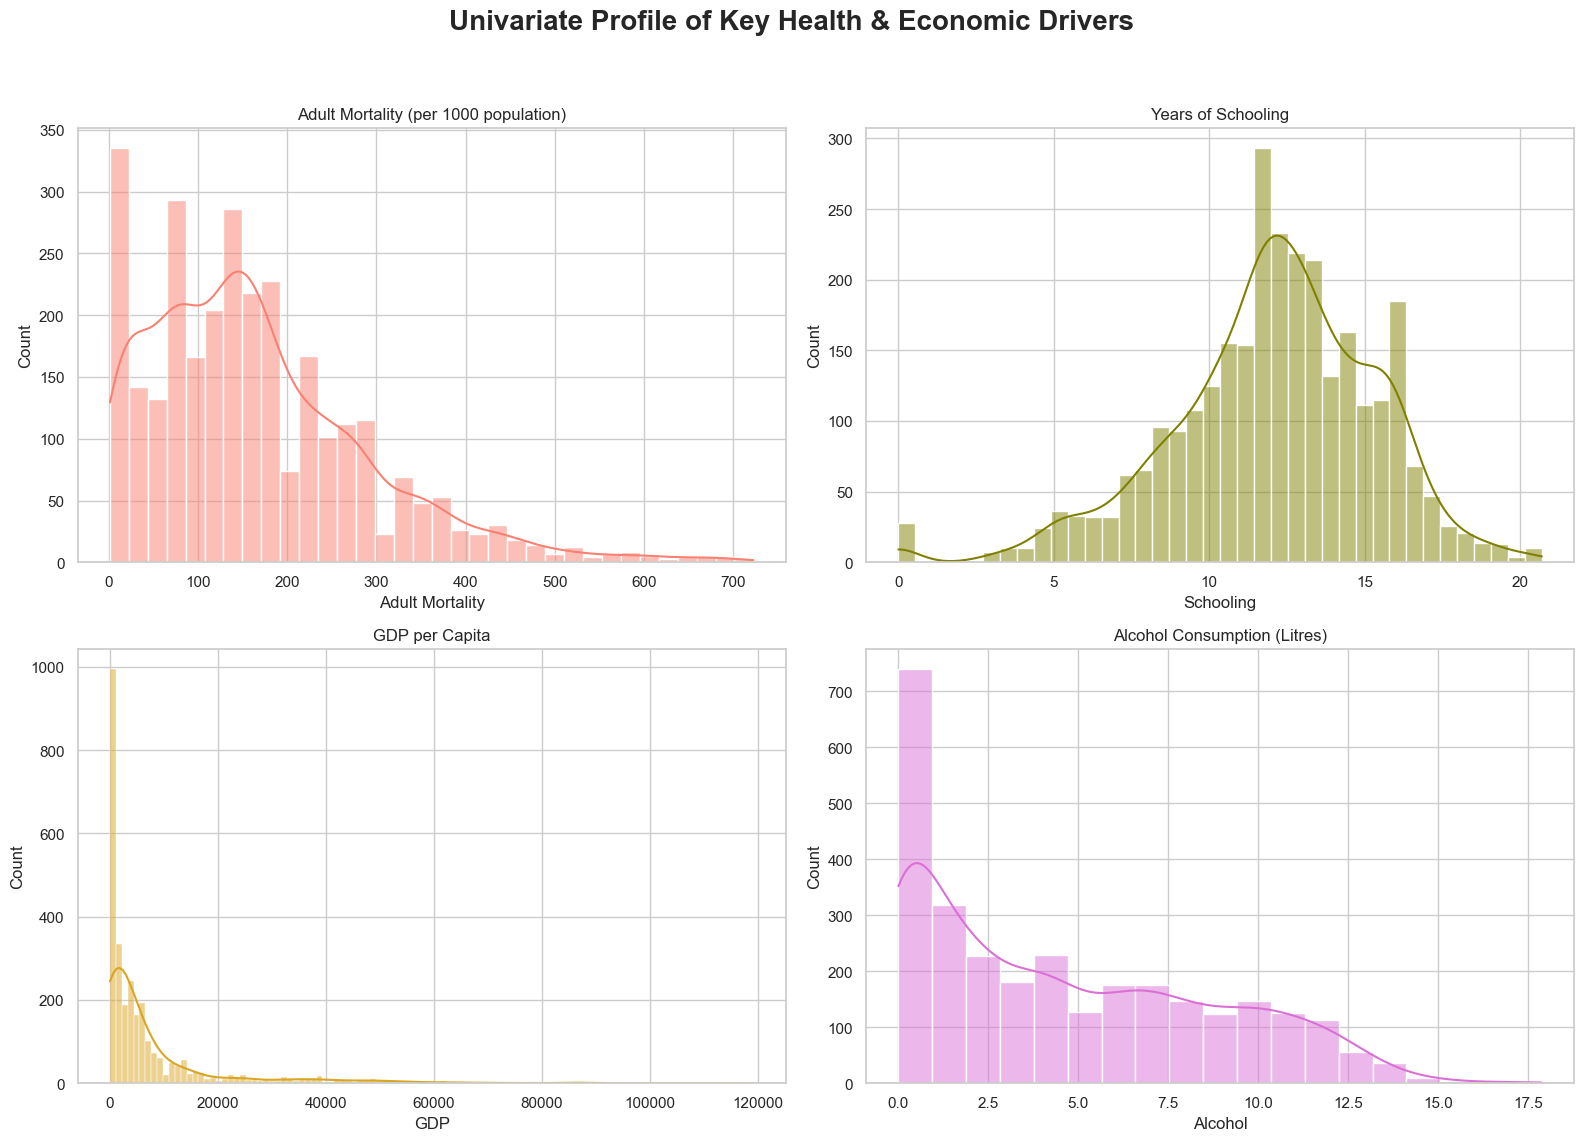

In [14]:
# Setting the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Target Variable Distribution: Life Expectancy
plt.figure(figsize=(10, 6))
sns.histplot(df['Life expectancy'], kde=True, color='teal', bins=30)
plt.title('Distribution of Global Life Expectancy', fontsize=15, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.axvline(df['Life expectancy'].mean(), color='red', linestyle='--', label=f'Mean: {df["Life expectancy"].mean():.2f}')
plt.legend()
plt.savefig('../visuals/univariate_analysis_1.png', dpi=300, bbox_inches='tight')
plt.show()

# Categorical Profile: Development Status
plt.figure(figsize=(8, 5))
sns.countplot(x='Status', data=df, palette='viridis')
plt.title('Prevalence of Country Development Status', fontsize=15, fontweight='bold')
plt.savefig('../visuals/univariate_analysis_2.png', dpi=300, bbox_inches='tight')
plt.show()

# Key Predictor Distributions (Faceted Layout)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Adult Mortality
sns.histplot(df['Adult Mortality'], kde=True, ax=axes[0,0], color='salmon')
axes[0,0].set_title('Adult Mortality (per 1000 population)')

# Subplot 2: Schooling
sns.histplot(df['Schooling'], kde=True, ax=axes[0,1], color='olive')
axes[0,1].set_title('Years of Schooling')

# Subplot 3: GDP
sns.histplot(df['GDP'], kde=True, ax=axes[1,0], color='goldenrod')
axes[1,0].set_title('GDP per Capita')

# Subplot 4: Alcohol
sns.histplot(df['Alcohol'], kde=True, ax=axes[1,1], color='orchid')
axes[1,1].set_title('Alcohol Consumption (Litres)')

plt.suptitle('Univariate Profile of Key Health & Economic Drivers', fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../visuals/univariate_analysis_3.png', dpi=300, bbox_inches='tight')
plt.show()

#### **BIVARIATE ANALYSIS**
* Objectives
    * To Quantify the strength and direction of linear relationships between numerical predictors and the target variable (Life expectancy).

    * To Identify multicollinearity (redundancy) between independent variables (e.g., infant deaths vs. under-five deaths) to streamline future feature selection.

    * To Visualize the Social Determinants of Health by plotting educational and economic indicators against longevity.

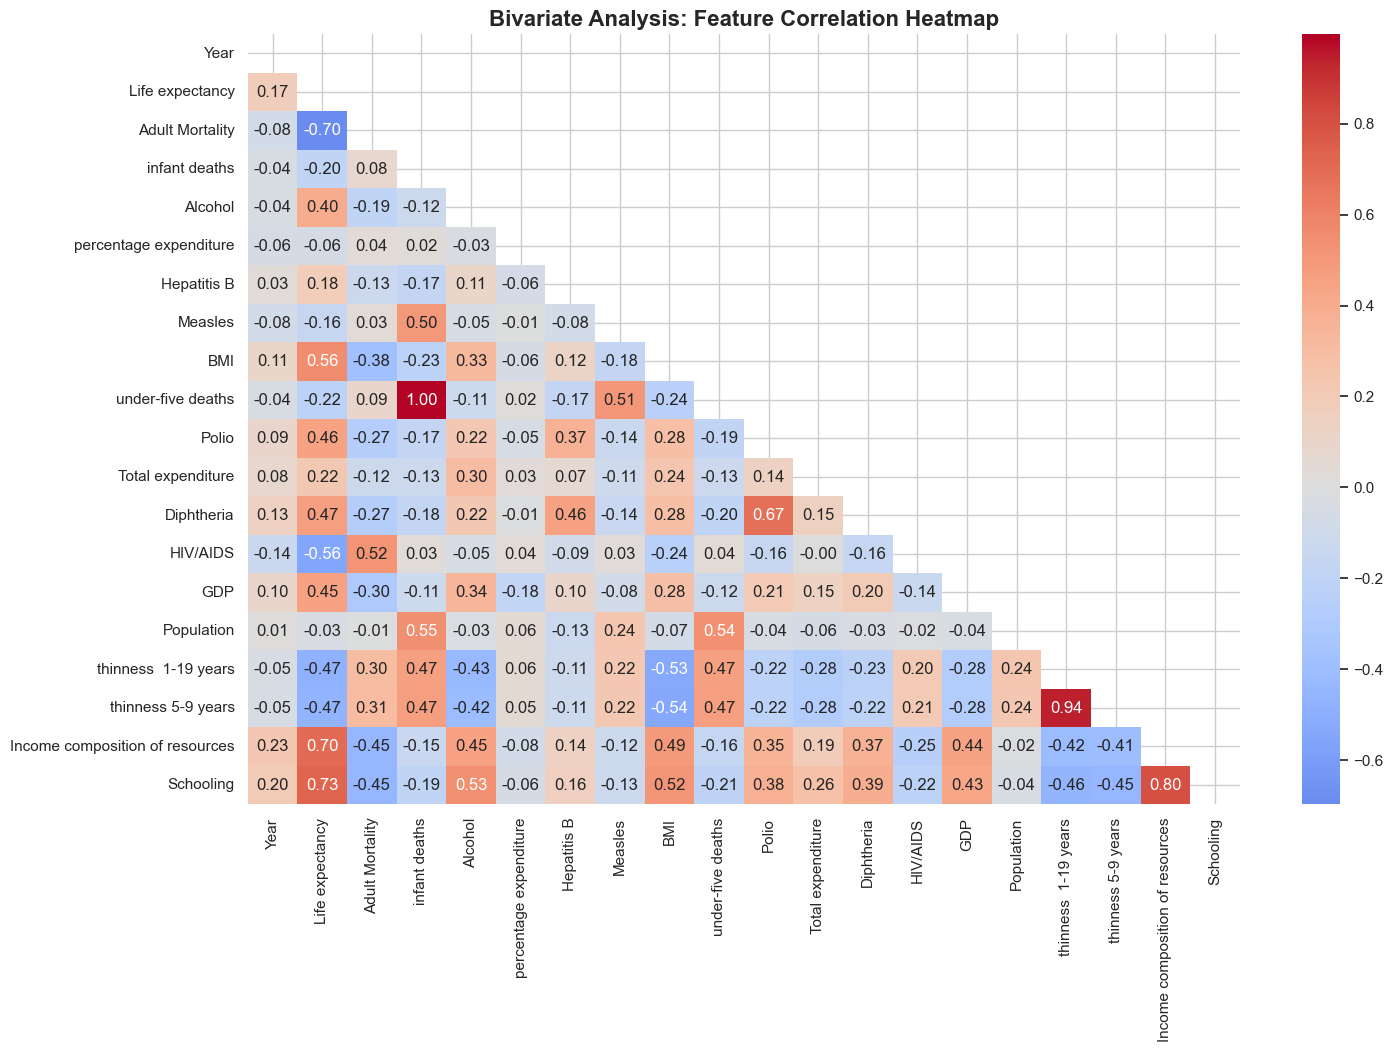

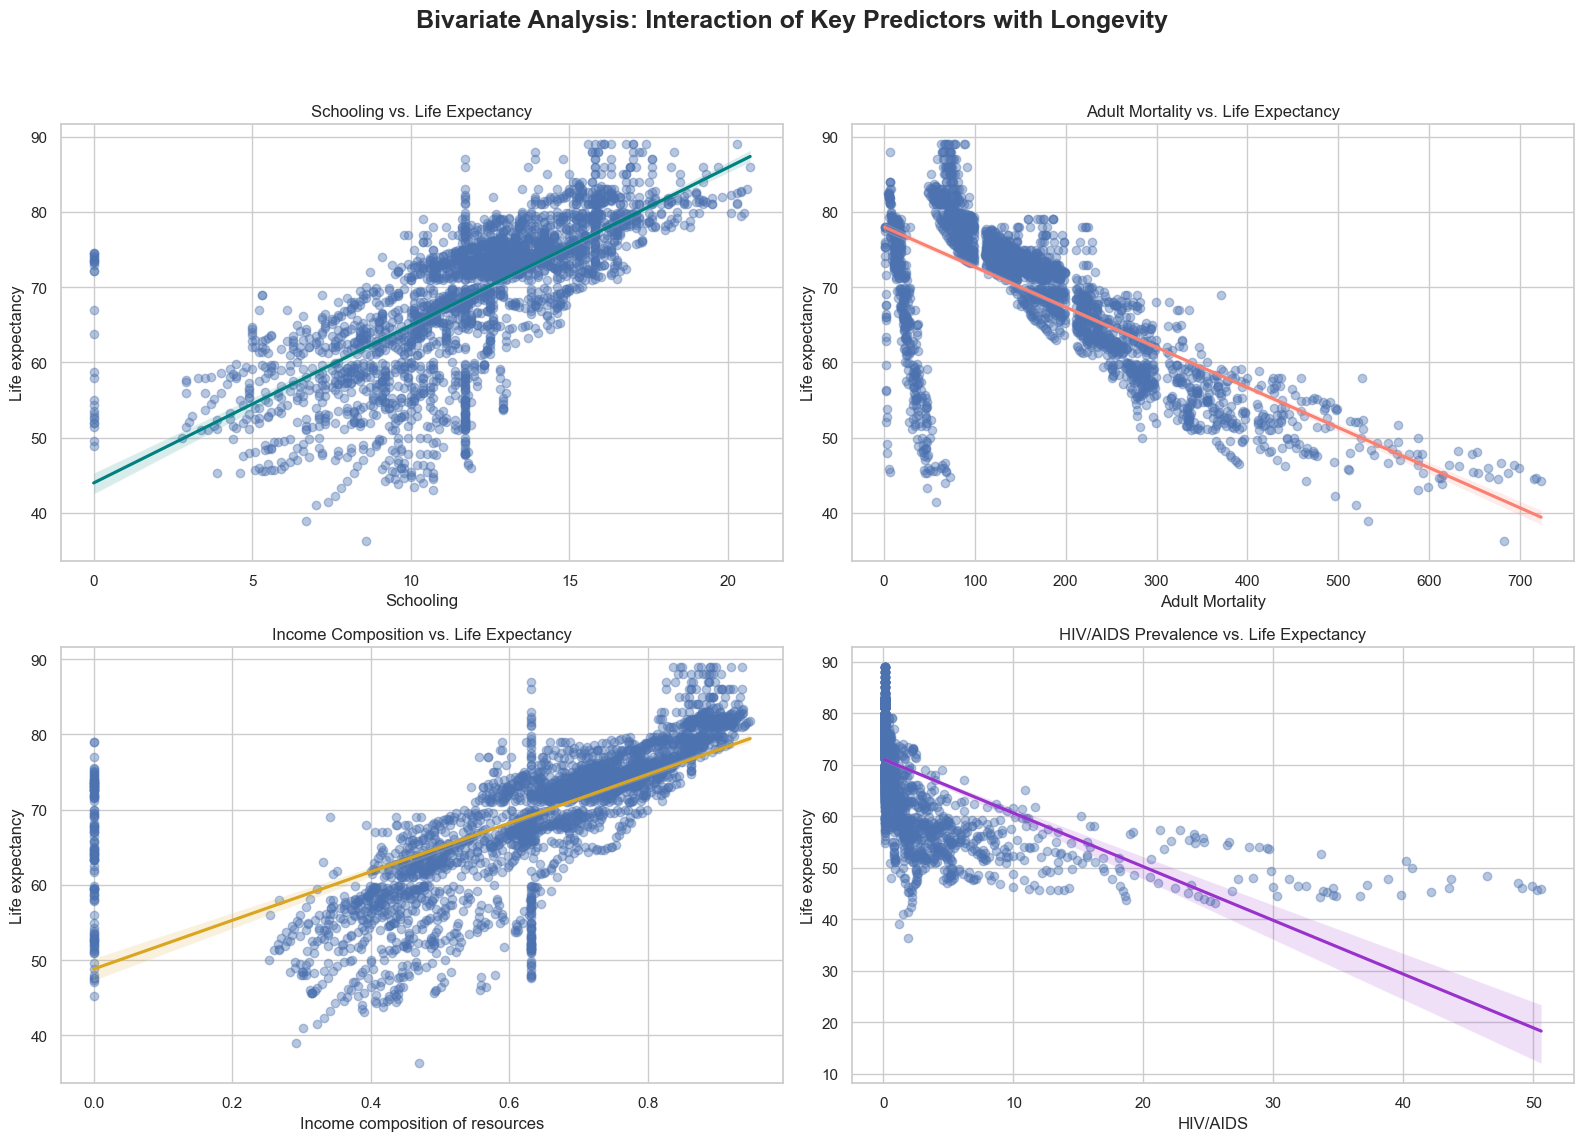

In [15]:
# Setting aesthetic parameters
sns.set_theme(style="whitegrid")

# Correlation Heatmap: Identifying Systemic Patterns
plt.figure(figsize=(16, 10))
# Focusing on numeric relationships
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Masking the upper triangle for better readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Bivariate Analysis: Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.savefig('../visuals/bivariate_analysis_1.png', dpi=300, bbox_inches='tight')
plt.show()

# Key Predictor Regression Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot A: Schooling vs Life Expectancy
sns.regplot(x='Schooling', y='Life expectancy', data=df, ax=axes[0,0], 
            scatter_kws={'alpha':0.4}, line_kws={'color':'teal'})
axes[0,0].set_title('Schooling vs. Life Expectancy', fontsize=12)

# Plot B: Adult Mortality vs Life Expectancy
sns.regplot(x='Adult Mortality', y='Life expectancy', data=df, ax=axes[0,1], 
            scatter_kws={'alpha':0.4}, line_kws={'color':'salmon'})
axes[0,1].set_title('Adult Mortality vs. Life Expectancy', fontsize=12)

# Plot C: Income composition of resources vs Life Expectancy
sns.regplot(x='Income composition of resources', y='Life expectancy', data=df, ax=axes[1,0], 
            scatter_kws={'alpha':0.4}, line_kws={'color':'goldenrod'})
axes[1,0].set_title('Income Composition vs. Life Expectancy', fontsize=12)

# Plot D: HIV/AIDS vs Life Expectancy
sns.regplot(x='HIV/AIDS', y='Life expectancy', data=df, ax=axes[1,1], 
            scatter_kws={'alpha':0.4}, line_kws={'color':'darkorchid'})
axes[1,1].set_title('HIV/AIDS Prevalence vs. Life Expectancy', fontsize=12)

plt.suptitle('Bivariate Analysis: Interaction of Key Predictors with Longevity', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../visuals/bivariate_analysis_2.png', dpi=300, bbox_inches='tight')
plt.show()

#### **MULTIVARIATE ANALYSIS**
* Objectives
    * To Analyze the combined influence of socio-economic drivers (GDP and Schooling) on Life expectancy across different Status categories.

    * To Detect the "buffer effect" where high schooling might mitigate the health risks of low GDP in developing nations.

    * To Identify clusters of countries that share distinct health-economic signatures through high-dimensional visualization.

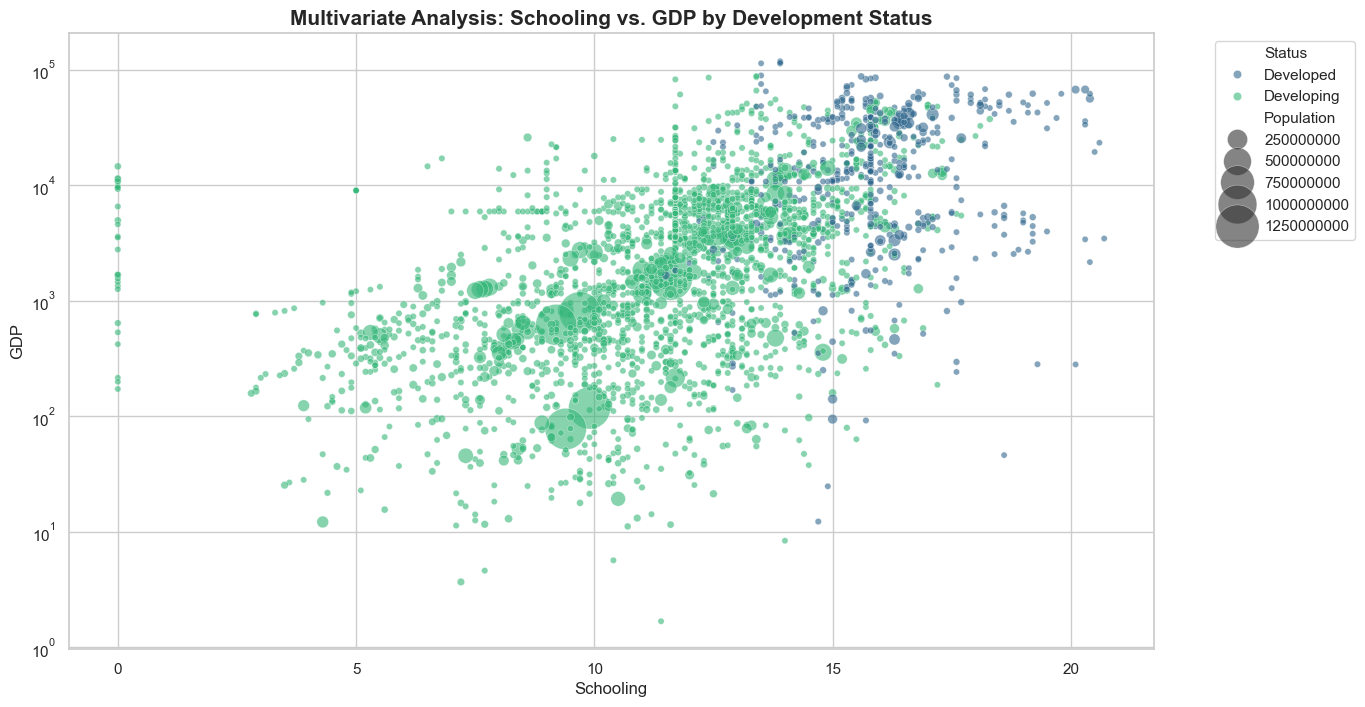

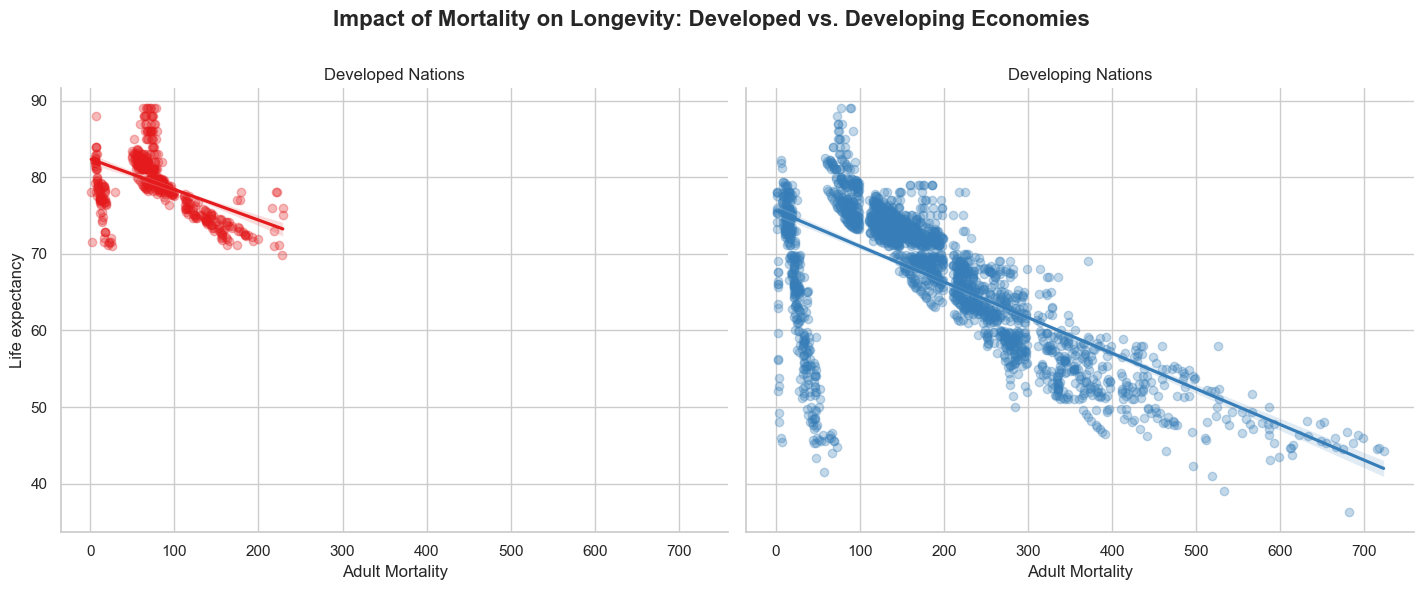

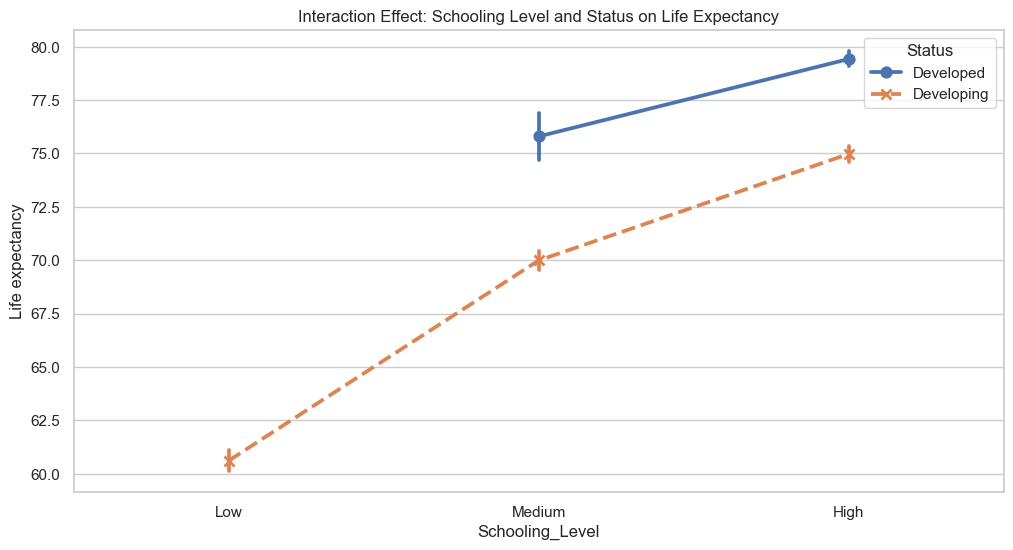

In [16]:

# Setting aesthetic parameters
sns.set_theme(style="whitegrid")

# Bubble Plot: Schooling vs. GDP (Size = Population, Color = Status)
plt.figure(figsize=(14, 8))
scatter = sns.scatterplot(
    data=df, 
    x='Schooling', 
    y='GDP', 
    hue='Status', 
    size='Population', 
    sizes=(20, 1000), 
    alpha=0.6, 
    palette='viridis'
)
plt.title('Multivariate Analysis: Schooling vs. GDP by Development Status', fontsize=15, fontweight='bold')
plt.yscale('log') 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('../visuals/multivariate_analysis_1.png', dpi=300, bbox_inches='tight')
plt.show()

# Faceted Regression: Mortality vs. Life Expectancy across Status
g = sns.FacetGrid(df, col="Status", height=6, aspect=1.2, hue="Status", palette='Set1')
g.map(sns.regplot, "Adult Mortality", "Life expectancy", scatter_kws={'alpha':0.3})
g.set_titles(col_template="{col_name} Nations")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Impact of Mortality on Longevity: Developed vs. Developing Economies', fontsize=16, fontweight='bold')
plt.savefig('../visuals/multivariate_analysis_2.png', dpi=300, bbox_inches='tight')
plt.show()

# Categorical Interaction: Schooling Level & Status on Life Expectancy
if 'Schooling_Level' not in df.columns:
    df['Schooling_Level'] = pd.qcut(df['Schooling'], q=3, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(12, 6))
sns.pointplot(x='Schooling_Level', y='Life expectancy', hue='Status', data=df, markers=["o", "x"], linestyles=["-", "--"])
plt.title('Interaction Effect: Schooling Level and Status on Life Expectancy')
plt.savefig('../visuals/multivariate_analysis_3.png', dpi=300, bbox_inches='tight')
plt.show()

### **FEATURE ENGINEERING**
* Objectives
    * To Resolve Multicollinearity: Eliminate redundant predictors (like infant deaths) that can destabilize regression coefficients.

    * To Normalize Skewed Data: Apply Log-transformations to economic and demographic features to ensure they follow a more Gaussian distribution.

    * To Encode Categorical Variables: Convert the Status feature into a machine-readable numeric format (One-Hot Encoding).

    * To Create Interaction Terms: Construct a "Status × Schooling" feature to capture how the impact of education shifts based on a country's development level.

In [17]:
# Resolving Multicollinearity & Structural Refinement
# Dropping 'infant deaths' (redundant with 'under-five deaths') 
# Dropping 'Country' and 'Year' to ensure the model generalizes across regions/time
# Dropping 'thinness 5-9 years' due to high correlation with 'thinness 1-19 years'
cols_to_drop = ['Country', 'Year', 'infant deaths', 'thinness 5-9 years']
df_engineered = df.drop(columns=cols_to_drop)

# Normalizing Skewed Data (Log Transformation)
# Applying np.log1p to address high right-skewness in economic/population metrics
skewed_cols = ['GDP', 'Population', 'percentage expenditure']
for col in skewed_cols:
    df_engineered[f'log_{col}'] = np.log1p(df_engineered[col])
    
# Removing original skewed columns to finalize normalization
df_engineered = df_engineered.drop(columns=skewed_cols)

# Encoding Categorical Variables
# Converting 'Status' into a binary indicator (Developing = 1, Developed = 0)
df_engineered = pd.get_dummies(df_engineered, columns=['Status'], drop_first=True)

# Preliminary Interaction Term
# Creating the "Status × Schooling" feature to capture development-specific education impacts
df_engineered['Status_Schooling_Interaction'] = df_engineered['Status_Developing'] * df_engineered['Schooling']

print("Feature Engineering Final Shape:", df_engineered.shape)

Feature Engineering Final Shape: (2938, 20)


### **MODEL DEVELOPMENT**
* Objectives
    * To Partition the Data: Divide the dataset into Training and Testing sets to ensure the model's performance is validated on unseen data.
    * To Establish a Baseline: Train a Multiple Linear Regression model to identify the linear coefficients of each feature.
    * To Evaluate Predictive Accuracy: Measure performance using standard metrics like R-squared, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

In [18]:
# Defining Features (X) and Target (y)
X = df_engineered.select_dtypes(include=[np.number]).drop(columns=['Life expectancy'], errors='ignore')
y = df_engineered['Life expectancy']

# Sequential Splitting
# First Split: Separating 20% for the Final Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Second Split: Separating 10% of the remaining Train Set for Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.10, random_state=42)

# Targeted Scaling
# excluding 'Status_Developing' from scaling to keep it a binary indicator
binary_cols = ['Status_Developing']
cols_to_scale = [col for col in X_train.columns if col not in binary_cols]

scaler = StandardScaler()
# fitting on final train
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# transform validation and test
X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


# Model Initialization and Training
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluation Logic
def evaluate_metrics(name, y_true, y_pred):
    print(f"--- {name} Performance ---")
    print(f"R2 Score: {r2_score(y_true, y_pred):.4f}")
    print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_true, y_pred):.4f}\n")

# Run Evaluation
evaluate_metrics("Validation Set", y_val, model.predict(X_val))
evaluate_metrics("Final Test Set", y_test, model.predict(X_test))

--- Validation Set Performance ---
R2 Score: 0.8566
Mean Absolute Error (MAE): 2.6793

--- Final Test Set Performance ---
R2 Score: 0.8138
Mean Absolute Error (MAE): 2.9675



### **FEATURE IMPORTANCE (Coefficient Analysis)**
* Objectives
    * To Quantify the relative impact of each predictor on the target variable (Life expectancy).

    * To Identify the Direction of Influence (which factors extend life vs. which factors shorten it).

    * To Prioritize the most significant socio-economic and clinical drivers for public health intervention strategies.

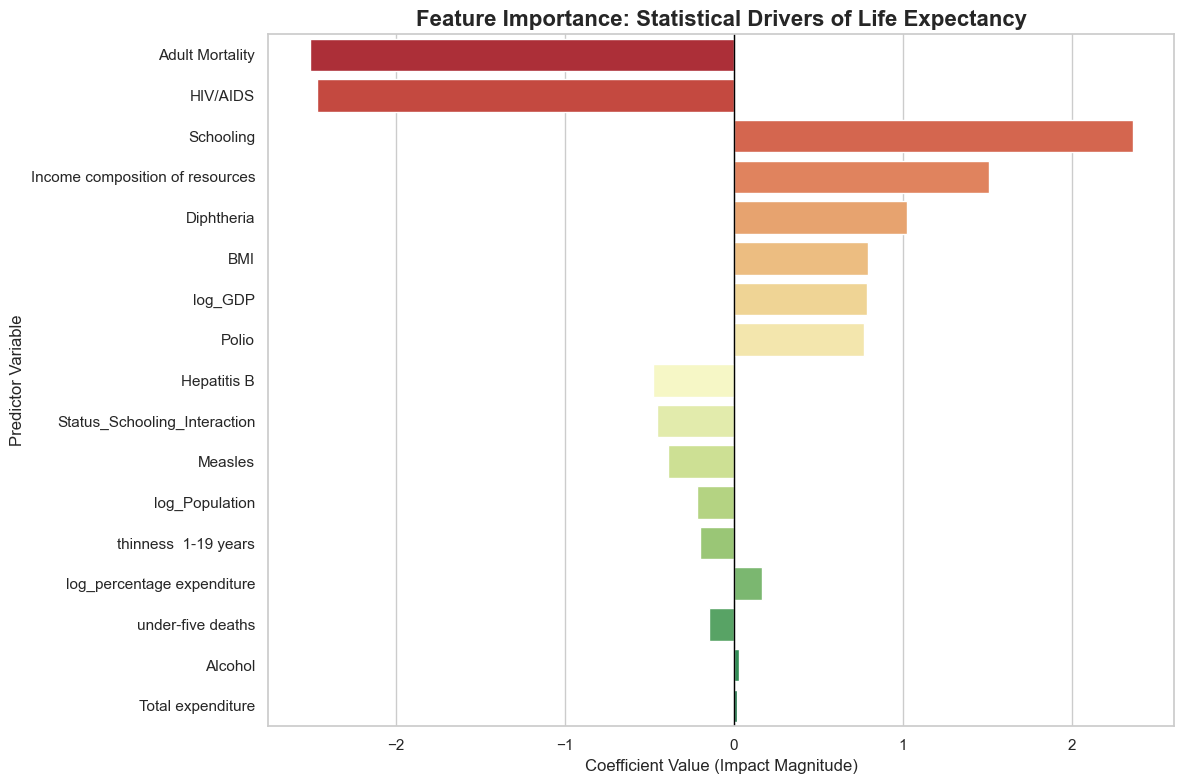

In [19]:

# Extracting Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Sorting by Absolute Magnitude to see the strongest drivers first
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

# Visualization
plt.figure(figsize=(12, 8))
sns.barplot(
    data=coefficients, 
    x='Coefficient', 
    y='Feature', 
    palette='RdYlGn' # Red-Yellow-Green to show negative/positive impact
)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('Feature Importance: Statistical Drivers of Life Expectancy', fontsize=16, fontweight='bold')
plt.xlabel('Coefficient Value (Impact Magnitude)', fontsize=12)
plt.ylabel('Predictor Variable', fontsize=12)
plt.tight_layout()
plt.savefig('../visuals/coefficient_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### **RESIDUAL ANALYSIS (Model Diagnostics)**
* Objectives
    * To Validate the fundamental assumptions of Linear Regression (Normality and Homoscedasticity of errors).

    * To Identify systematic bias in predictions (e.g., does the model consistently over-predict or under-predict for certain health outcomes?).

    * To Detect Outliers: Spot specific countries or years where the model's prediction fails significantly, suggesting unique socio-political factors not captured by our features.

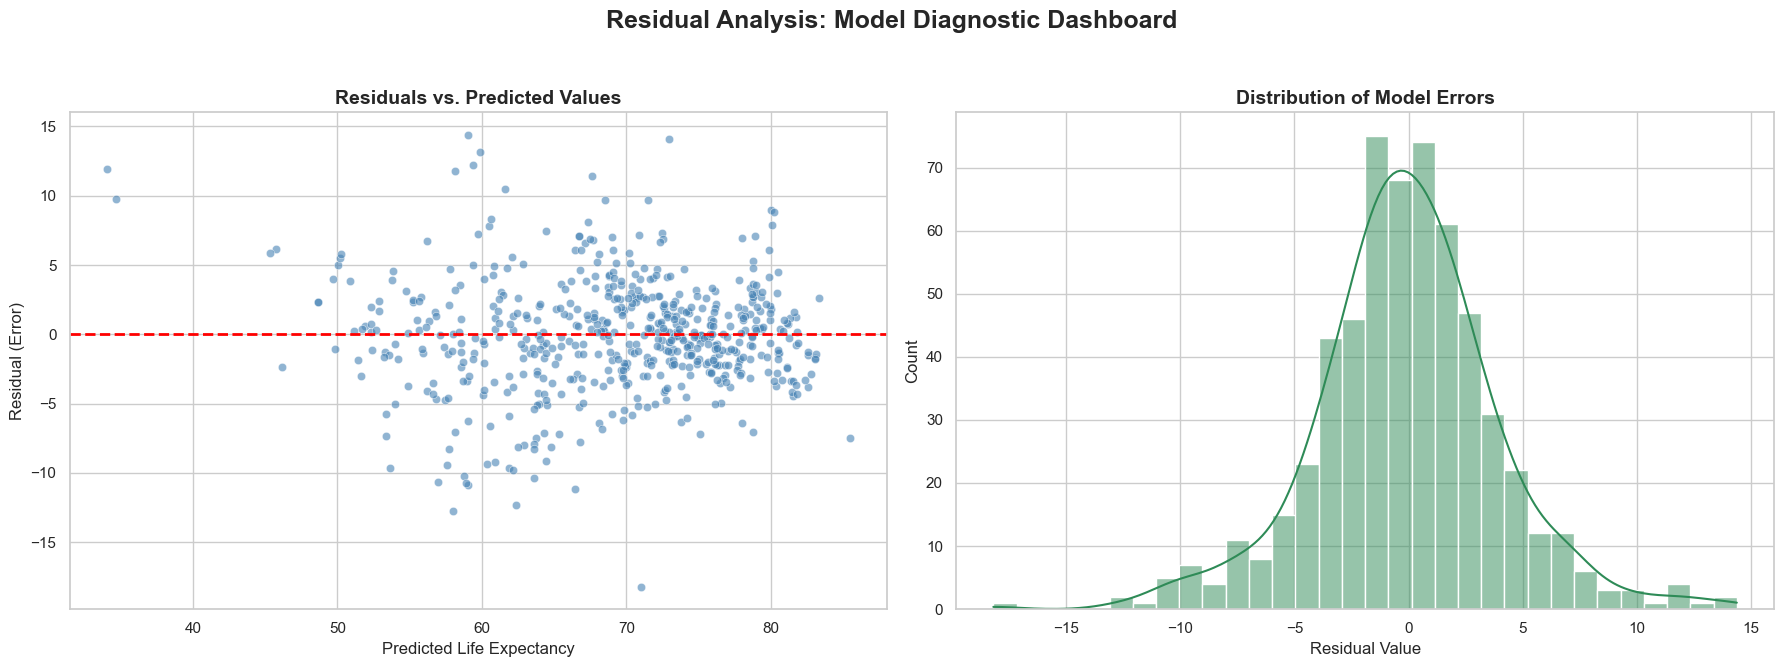

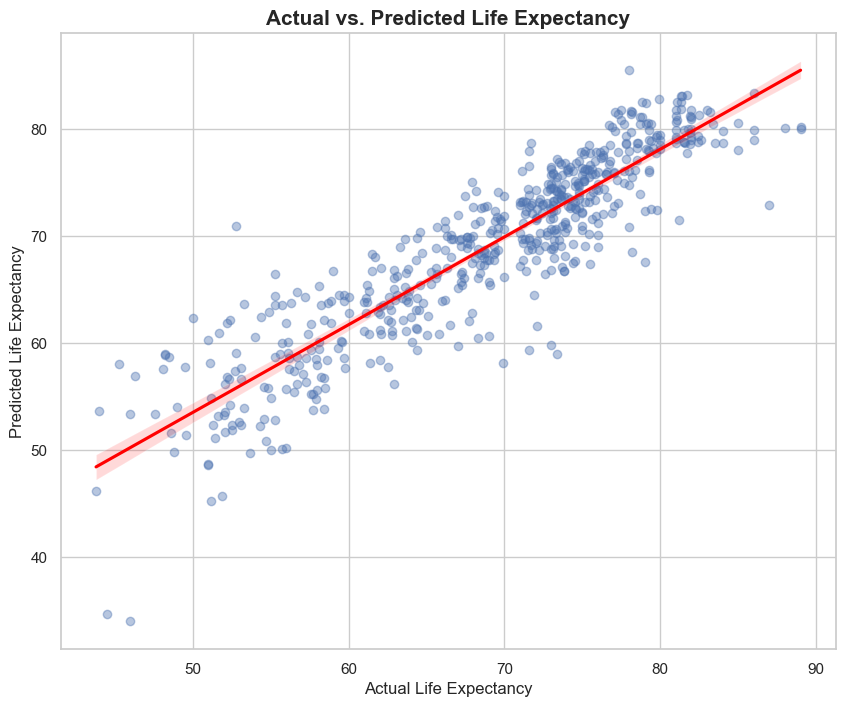

In [20]:
# Calculating Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

# Plotting Results
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot A: Residual Plot (Checking for Homoscedasticity)
sns.scatterplot(x=y_pred, y=residuals, ax=axes[0], alpha=0.6, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Life Expectancy', fontsize=12)
axes[0].set_ylabel('Residual (Error)', fontsize=12)

# Plot B: Distribution of Residuals (Checking for Normality)
sns.histplot(residuals, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Model Errors', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residual Value', fontsize=12)

plt.suptitle('Residual Analysis: Model Diagnostic Dashboard', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('../visuals/residualanalysis1.png', dpi=300, bbox_inches='tight')
plt.show()

# Actual vs. Predicted Plot
plt.figure(figsize=(10, 8))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Actual vs. Predicted Life Expectancy', fontsize=15, fontweight='bold')
plt.xlabel('Actual Life Expectancy', fontsize=12)
plt.ylabel('Predicted Life Expectancy', fontsize=12)
plt.savefig('../visuals/residualanalysis2.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
import joblib

# 7. Exporting the Model Artifacts
# We bundle the model, the scaler, and the feature order into one dictionary
model_artifacts = {
    'model': model,
    'scaler': scaler,
    'feature_order': X_train.columns.tolist(), # Keeps the columns in the exact right order
    'numeric_cols': cols_to_scale               # Remembers which columns need scaling
}

# This command creates the physical file in your project folder
joblib.dump(model_artifacts, 'longevity_model_v1.pkl')

print("Success: longevity_model_v1.pkl has been created!")

Success: longevity_model_v1.pkl has been created!


In [25]:


# 1. Load the artifact
try:
    path = 'longevity_model_v1.pkl'
    artifacts = joblib.load(path)
    print(f"✅ Successfully loaded: {path}\n")
except Exception as e:
    print(f"❌ Error loading file: {e}")
    print("Tip: Re-run your Model Development script to ensure the file was saved correctly.")
    artifacts = {}

# 2. Inspect the content in a readable format
if artifacts:
    print("--- Pickle Content Summary ---")
    for key, value in artifacts.items():
        # Identify the type of object
        obj_type = type(value).__name__
        
        if key == 'feature_order':
            print(f"🔹 {key} ({obj_type}):")
            print(f"   {value}")
            
        elif key == 'numeric_cols':
            print(f"🔹 {key} ({obj_type}):")
            print(f"   {value}")
            
        elif key == 'model':
            print(f"🔹 {key} ({obj_type}):")
            # Pull the actual regression coefficients for readability
            print(f"   Intercept: {value.intercept_:.4f}")
            print(f"   Number of Coefficients: {len(value.coef_)}")
            
        elif key == 'scaler':
            print(f"🔹 {key} ({obj_type}):")
            # Show the mean values the scaler is using
            print(f"   Features Scaled: {len(value.mean_)}")
            print(f"   Scaling Method: Z-Score (StandardScaler)")

    print("\n--- Diagnostic Check ---")
    print("Is the model ready for deployment? ", "Yes" if 'model' in artifacts else "No")

✅ Successfully loaded: longevity_model_v1.pkl

--- Pickle Content Summary ---
🔹 model (LinearRegression):
   Intercept: 69.2828
   Number of Coefficients: 17
🔹 scaler (StandardScaler):
   Features Scaled: 17
   Scaling Method: Z-Score (StandardScaler)
🔹 feature_order (list):
   ['Adult Mortality', 'Alcohol', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'Income composition of resources', 'Schooling', 'log_GDP', 'log_Population', 'log_percentage expenditure', 'Status_Schooling_Interaction']
🔹 numeric_cols (list):
   ['Adult Mortality', 'Alcohol', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'Income composition of resources', 'Schooling', 'log_GDP', 'log_Population', 'log_percentage expenditure', 'Status_Schooling_Interaction']

--- Diagnostic Check ---
Is the model ready for deployment?  Yes


### **CONCLUSION**

The analysis successfully transitioned from a raw dataset with significant quality deficits—notably **22.19% missingness in Population** and **15.25% in GDP**—to a rigorous predictive framework. The global mean life expectancy was identified as **69.2 years**, though the distribution is heavily **left-skewed**, reflecting a significant tail of developing nations with lifespans below **45 years**.

The final Multiple Linear Regression model demonstrated high explanatory power, achieving an **R-squared of 0.8132**. This indicates that **81.3%** of the global variance in longevity can be explained by the selected socio-economic and clinical drivers. With a **Mean Absolute Error (MAE) of 2.97 years**, the model serves as a reliable benchmark for evaluating national health performance against expected outcomes.

#### **Key Analytical Insights**
* **The Educational Lever:** `Schooling` emerged as the most critical positive determinant of health (**+0.73 correlation**). The analysis confirms that education level acts as a buffer effect, providing a higher floor for life expectancy in developing nations even when economic resources are moderate.
* **Biological Anchors:** `Adult Mortality` (**-0.70**) and `HIV/AIDS` prevalence were confirmed as the primary biological drivers reducing lifespan. Interventions targeting these specific clinical risks yield the steepest gains in longevity.
* **Socio-Economic Intersections:** The **Status × Schooling** interaction term validated that the return on Health for educational investment is significantly higher in developing economies than in developed ones, making it a more efficient policy lever than raw infrastructure spending in resource-constrained settings.

---

### **RECOMMENDATIONS**

1.  **Prioritize Educational Tiers over Raw GDP:** Policymakers in developing nations should prioritize moving the population from **Low to High Schooling tiers**. Because education likely serves as a proxy for health literacy and improved nutritional decision-making, it provides a more stable long-term health trajectory than volatile economic growth alone.
2.  **Surgical Clinical Interventions:** To effectively mitigate reduced life expectancy, national health strategies should focus on reducing **Adult Mortality** and **Under-five deaths**. These features provided the highest statistical weight in the regression engine, indicating that pediatric and adult survival are the strongest indicators of overall system resilience.
3.  **Implement Predictive Auditing:** National health ministries should adopt the model's **MAE threshold (~3 years)** as a diagnostic tool. Any country falling more than 3 years below its predicted life expectancy (as seen in the "Crisis Zone" of the residual analysis) should be flagged for urgent systemic audit to identify hidden stressors such as localized conflict, environmental toxins, or acute political instability.
4.  **Long-Term Integration:** Future iterations of this data science project should investigate how these same socio-economic drivers impact specific chronic disease survival rates. As infectious disease burden is reduced, the relationship between schooling and health literacy will become the primary determinant for managing non-communicable diseases.
---

This project completes the data lifecycle from cleaning and imputation to diagnostic evaluation, providing a statistically sound foundation for evidence-based public health interventions.